# Project 2: Loan Approval Prediction (Classification)

## Internship Machine Learning Project

### Objective
The objective of this project is to build a classification model that predicts whether a loan application will be approved based on socio-economic and credit-related features.

### Problem Type
This is a supervised binary classification problem where:
- Target Variable: Loan_Status
- Classes: Approved (Y) / Not Approved (N)

# Importing all Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# 1. Load & Explore Dataset

In [2]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\IIT Internship\loan_approval_dataset.csv")

df.columns = df.columns.str.strip().str.lower()

df_original = df.copy()
df_eda = df.copy()

df_eda.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# 2. Data Cleaning & Preprocessing

In [3]:
df.shape

(4269, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## 2.1 Handling Missing Values

In [6]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

## 2.2 Encoding Categorical Variables

In [7]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [8]:
df = df_original.copy()
le = LabelEncoder()
df["education"] = le.fit_transform(df["education"])
df["self_employed"] = le.fit_transform(df["self_employed"])
df["loan_status"] = le.fit_transform(df["loan_status"])
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


## 2.3 Handling Class Imbalance

In [9]:
df["loan_status"].value_counts()

loan_status
0    2656
1    1613
Name: count, dtype: int64

In [10]:
df["loan_status"].value_counts(normalize=True) * 100

loan_status
0    62.215976
1    37.784024
Name: proportion, dtype: float64

# 3. Exploratory Data Analysis (EDA)

## 3.1 Correlation Matrix

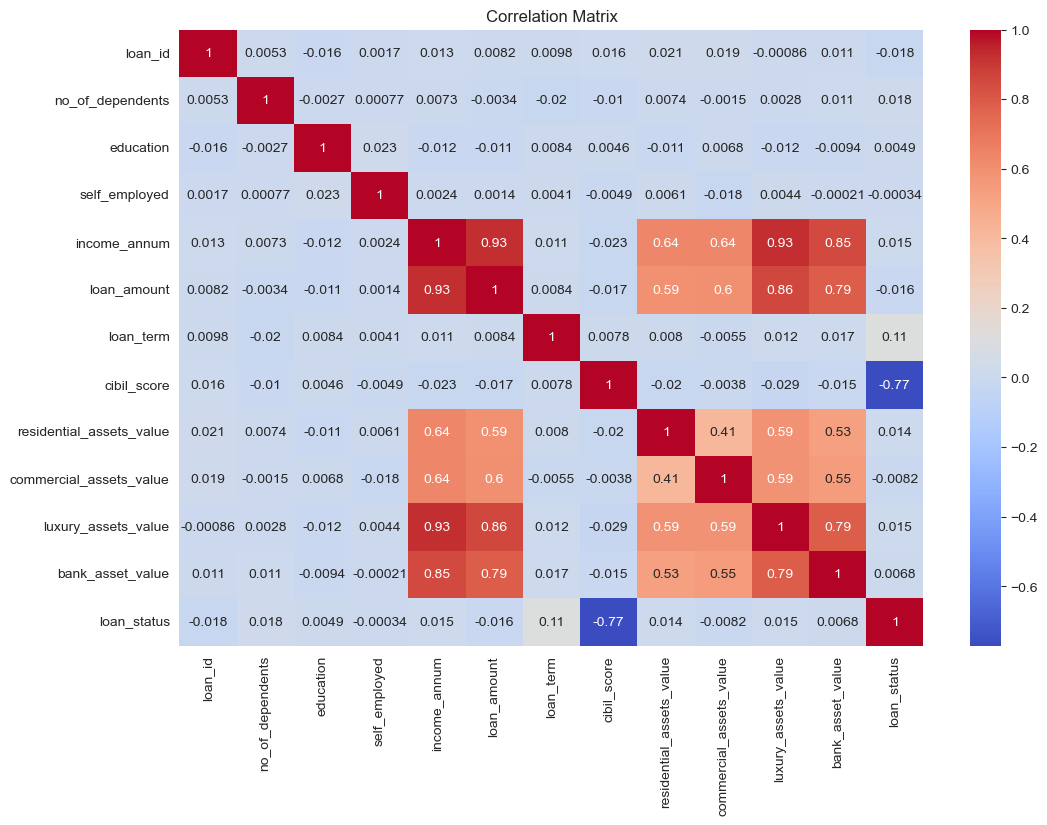

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Insight:** CIBIL score shows the strongest relationship with loan approval, indicating credit history is the key deciding factor.

## 3.2 Loan Approval by Education

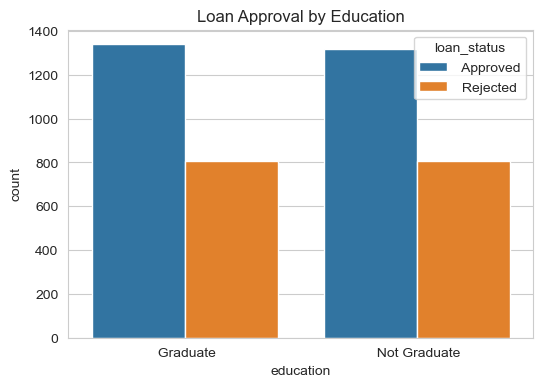

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="education", hue="loan_status", data=df_eda)
plt.title("Loan Approval by Education")
plt.show()

**Insight:** Education does not significantly impact loan approval, as both graduates and non-graduates show similar approval patterns.

## 3.3 Loan Approval by Employment Status

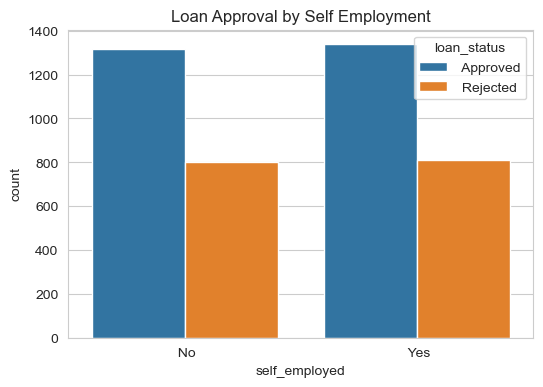

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="self_employed", hue="loan_status", data=df_eda)
plt.title("Loan Approval by Self Employment")
plt.show()

**Insight:** Approval rates are similar for both self-employed and non-self-employed applicants, indicating employment type has limited impact on loan decisions.

## 3.4 Distribution of Applicant Income

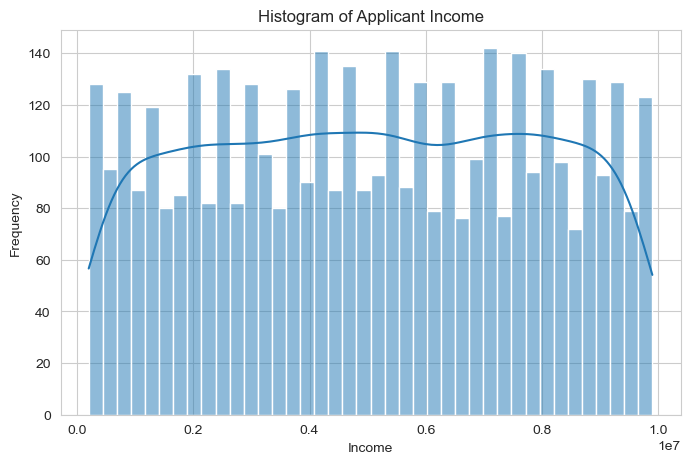

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["income_annum"], bins=40, kde=True)
plt.title("Histogram of Applicant Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

## 3.5 Income Distribution by Loan Status

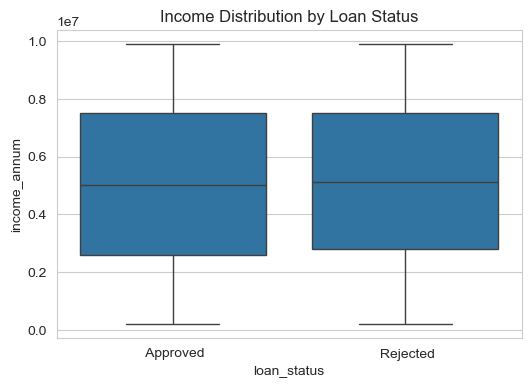

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x="loan_status", y="income_annum", data=df_eda)
plt.title("Income Distribution by Loan Status")
plt.show()

**Insight:** Income levels are similar across approved and rejected applicants, suggesting income alone is not a strong predictor of approval.

## 3.6 Key Numerical Feature Analysis

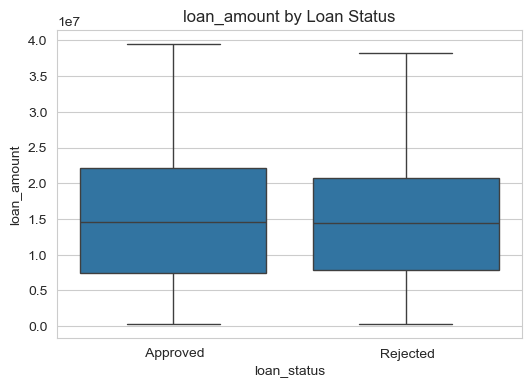

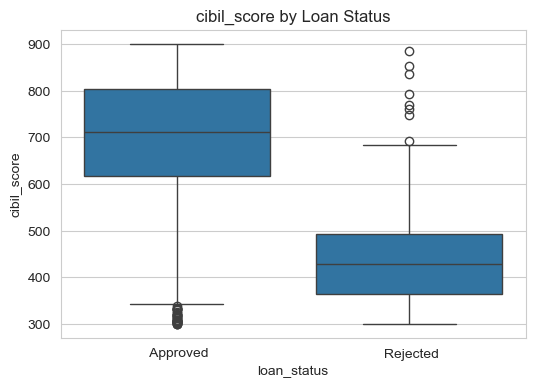

In [16]:
numerical_cols = ["loan_amount", "cibil_score"]
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="loan_status", y=col, data=df_eda)
    plt.title(f"{col} by Loan Status")
    plt.show()

**Insight:** Loan amount shows significant overlap between approved and rejected cases, indicating it is not a strong standalone predictor.
    **Insight:** Approved applicants have noticeably higher CIBIL scores than rejected ones, making credit score the strongest deciding factor.

## 4. Data Optimization Before Modeling

# 4.1 Outlier Detection and Removal (IQR Method)

In [17]:
df_model = df.copy()
numerical_cols = [
    "income_annum",
    "loan_amount",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]
for col in numerical_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_model = df_model[(df_model[col] >= lower) & (df_model[col] <= upper)]
df_model.shape

(4173, 13)

## 4.2 Feature Scaling

In [18]:
X = df_model.drop(["loan_status", "loan_id"], axis=1)
y = df_model["loan_status"]
numerical_cols = [
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
1,0,1,1,-0.311364,-0.297962,-0.505247,-1.063084,-0.730512,-0.622704,-0.673448,-0.493590
2,3,0,0,1.501660,1.663530,1.597541,-0.546621,-0.013423,-0.075652,2.053095,2.505374
3,3,0,0,1.175316,1.775615,-0.505247,-0.772936,1.795598,-0.361070,0.940220,0.958540
4,5,1,1,1.755483,1.047061,1.597541,-1.266187,0.850344,0.804387,1.619074,0.043067
5,0,0,1,-0.057541,-0.152251,-0.154782,-1.631773,-0.062316,0.828172,-0.128139,0.074635


## 4.3 Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape

((3338, 11), (835, 11))

# 5. Model Building

## 5.1 Logistic Regression`

In [20]:
log_model = LogisticRegression(class_weight="balanced", max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.9233532934131736
Precision: 0.8724035608308606
Recall: 0.9333333333333333
F1 Score: 0.901840490797546


## 5.2 Decision Tree

In [21]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.9760479041916168
Precision: 0.9682539682539683
Recall: 0.9682539682539683
F1 Score: 0.9682539682539683


## 5.3 Random Forest

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9760479041916168
Precision: 0.9682539682539683
Recall: 0.9682539682539683
F1 Score: 0.9682539682539683


## 5.4 Gradient Boosting 

In [23]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))

Accuracy: 0.9808383233532935
Precision: 0.9776357827476039
Recall: 0.9714285714285714
F1 Score: 0.9745222929936306


# 6. Model Evaluation

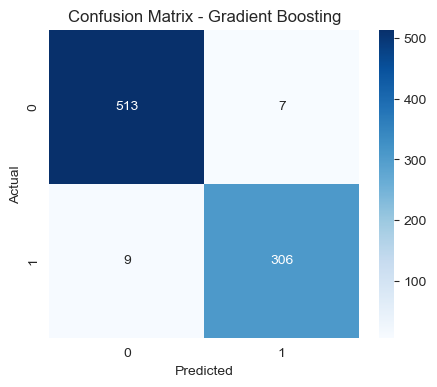

array([[513,   7],
       [  9, 306]])

In [24]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

cm

## 6.1 ROC-AUC Score and Curve

ROC-AUC Score: 0.9967704517704519


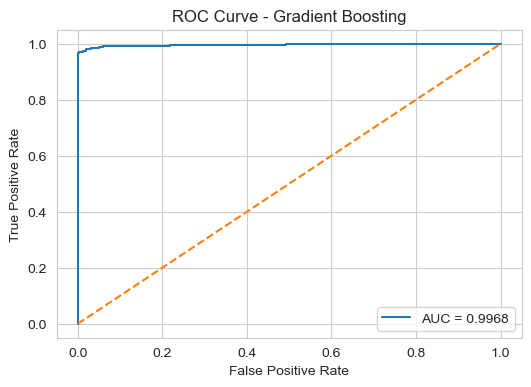

In [25]:
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob_gb)
print("ROC-AUC Score:", roc_auc)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

## 6. Model Comparison & Interpretation

In [26]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.923353,0.872404,0.933333,0.901840
1,Decision Tree,0.976048,0.968254,0.968254,0.968254
2,Random Forest,0.976048,0.968254,0.968254,0.968254
3,Gradient Boosting,0.980838,0.977636,0.971429,0.974522


## 6.2 Cross-Validation

In [27]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.9748503  0.97844311 0.98083832 0.97841727 0.98561151]
Mean CV Accuracy: 0.9796321027010727


## 6.3 Feature Importance

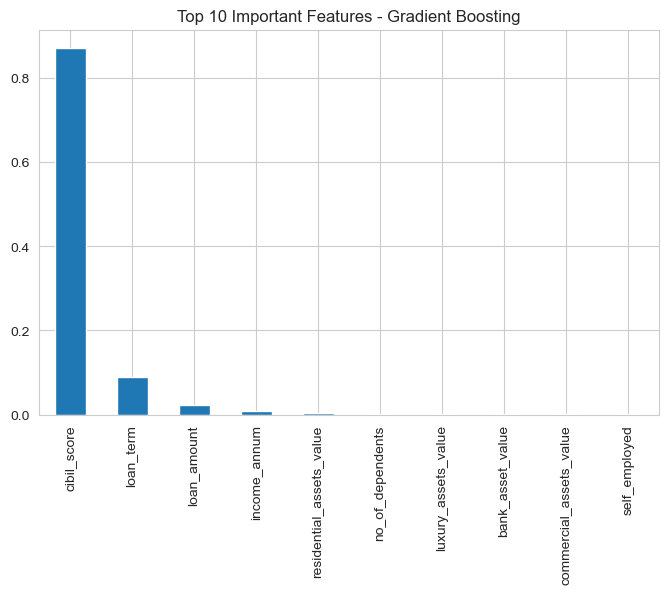

cibil_score                 0.870926
loan_term                   0.088138
loan_amount                 0.022332
income_annum                0.008271
residential_assets_value    0.002703
no_of_dependents            0.002204
luxury_assets_value         0.002044
bank_asset_value            0.001712
commercial_assets_value     0.001485
self_employed               0.000179
dtype: float64

In [28]:
importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(8,5))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features - Gradient Boosting")
plt.show()
importance.head(10)

## 6.3 Probability-Based Decision Strategy

In [29]:
y_prob = gb_model.predict_proba(X_test)[:, 1]

pd.DataFrame({
    "Actual": y_test.values,
    "Approval_Probability": y_prob
}).head()

,Actual,Approval_Probability
0,0,0.002692
1,1,0.998012
2,0,0.001840
3,0,0.000555
4,1,0.998404


# 7. Predict Loan Approval for New Applicant

In [30]:
new_applicant = {
    "no_of_dependents": 2,
    "education": 1,          # 1 = Graduate (use same encoding as your dataset)
    "self_employed": 0,      # 0 = No
    "income_annum": 500000,
    "loan_amount": 200000,
    "loan_term": 12,
    "cibil_score": 750,
    "residential_assets_value": 100000,
    "commercial_assets_value": 0,
    "luxury_assets_value": 50000,
    "bank_asset_value": 150000
}

In [31]:
print(X.columns)

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')


In [32]:
new_df = pd.DataFrame([new_applicant])
new_df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,1,0,500000,200000,12,750,100000,0,50000,150000


In [33]:
new_df[numerical_cols] = scaler.transform(new_df[numerical_cols])

In [34]:
probability = gb_model.predict_proba(new_df)[:, 1][0]
print("Approval Probability:", round(probability, 3))

Approval Probability: 0.494


In [35]:
threshold = 0.5

if probability >= 0.7:
    print("Low Risk – Safe to Approve ✅")
elif probability >= 0.5:
    print("Medium Risk – Manual Review ⚠")
else:
    print("High Risk – Reject ❌")

High Risk – Reject ❌


In [36]:
# Multiple new applicants

new_applicants = [
    {
        'no_of_dependents': 1,
        'education': 1,
        'self_employed': 0,
        'income_annum': 800000,
        'loan_amount': 250000,
        'loan_term': 12,
        'cibil_score': 780,
        'residential_assets_value': 200000,
        'commercial_assets_value': 0,
        'luxury_assets_value': 100000,
        'bank_asset_value': 300000
    },
    {
        'no_of_dependents': 3,
        'education': 0,
        'self_employed': 1,
        'income_annum': 300000,
        'loan_amount': 400000,
        'loan_term': 24,
        'cibil_score': 620,
        'residential_assets_value': 50000,
        'commercial_assets_value': 0,
        'luxury_assets_value': 20000,
        'bank_asset_value': 40000
    },
    {
        'no_of_dependents': 2,
        'education': 1,
        'self_employed': 0,
        'income_annum': 600000,
        'loan_amount': 200000,
        'loan_term': 12,
        'cibil_score': 750,
        'residential_assets_value': 150000,
        'commercial_assets_value': 0,
        'luxury_assets_value': 50000,
        'bank_asset_value': 120000
    }
]

In [37]:
multi_df = pd.DataFrame(new_applicants)
multi_df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1,1,0,800000,250000,12,780,200000,0,100000,300000
1,3,0,1,300000,400000,24,620,50000,0,20000,40000
2,2,1,0,600000,200000,12,750,150000,0,50000,120000


In [38]:
multi_df[numerical_cols] = scaler.transform(multi_df[numerical_cols])

In [39]:
probabilities = gb_model.predict_proba(multi_df)[:, 1]
probabilities

array([0.05055447, 0.61473778, 0.45734295])

In [40]:
threshold = 0.5

decisions = []

for prob in probabilities:
    if prob >= threshold:
        decisions.append("Approved ✅")
    else:
        decisions.append("Rejected ❌")

multi_df["Approval_Probability"] = probabilities
multi_df["Decision"] = decisions

multi_df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,Approval_Probability,Decision
0,1,1,0,-1.507960,-1.637380,0.195682,1.043389,-1.137950,-1.14597,-1.641649,-1.440631,0.050554,Rejected ❌
1,3,0,1,-1.689262,-1.620568,2.298470,0.114916,-1.162396,-1.14597,-1.650552,-1.522708,0.614738,Approved ✅
2,2,1,0,-1.580480,-1.642985,0.195682,0.869300,-1.146098,-1.14597,-1.647213,-1.497454,0.457343,Rejected ❌


# Final Project Conclusion

This project developed a loan approval prediction system using multiple machine learning models.

Gradient Boosting emerged as the best-performing model with:

- 98.08% Accuracy
- 97.45% F1 Score
- 0.9968 ROC-AUC
- 97.96% Cross-Validation Accuracy

CIBIL score was identified as the most influential feature, demonstrating the importance of credit history in financial risk assessment.

The model shows strong generalization capability and can be deployed in real-world banking systems to automate and optimize loan approval decisions.

### Practical Implementation in Banking

A bank can integrate this model into its loan processing system to:

- Predict approval probability for each applicant.
- Automatically flag high-risk applications.
- Reduce manual verification time.
- Improve consistency in decision-making.
- Lower default risk by relying on data-driven evaluation.

The model can generate a probability score, allowing the bank to adjust approval thresholds based on risk appetite.

# 8. Business Intelligence Integration (Power BI)

The trained Gradient Boosting model outputs were exported and visualized using Power BI to enable interactive risk monitoring and business decision support.

In [41]:
final_df = df_model.copy()
final_df = final_df.loc[X_test.index]

final_df["Actual_Status"] = y_test.values
final_df["Predicted_Status"] = y_pred_gb
final_df["Approval_Probability"] = y_prob

final_df.to_csv("loan_dashboard_data.csv", index=False)

final_df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,Actual_Status,Predicted_Status,Approval_Probability
505,506,4,0,1,2000000,7200000,10,838,2500000,300000,7600000,1000000,0,0,0,0.002692
3806,3807,0,1,0,1300000,3400000,10,464,1200000,200000,3500000,1400000,1,1,1,0.998012
2988,2989,1,0,1,9300000,19000000,14,689,24000000,11500000,35100000,9000000,0,0,0,0.001840
2339,2340,2,0,0,8200000,22500000,18,857,13400000,14300000,28400000,8400000,0,0,0,0.000555
497,498,2,1,0,8100000,24800000,6,307,200000,4000000,31100000,10500000,1,1,1,0.998404


## 10. Power BI Deployment

The trained Gradient Boosting model probabilities were exported and integrated into Power BI to build an interactive executive dashboard. The dashboard enables dynamic threshold simulation and real-time risk segmentation for decision-making.